In [1]:
# STEP 1 : IMPORT REQUIRED LIBRARIES

# Import pandas for data analysis
import pandas as pd

# Import matplotlib for plotting graphs
import matplotlib.pyplot as plt

# Import seaborn for advanced visualizations
import seaborn as sns

In [2]:
# STEP 2 : LOAD THE CLEAN DATASET

# Read the cleaned dataset
df = pd.read_csv("clean_cafe_sales.csv")

# Display first 5 rows
df.head()

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,TXN_1961373,Coffee,2.0,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4.0,3.0,12.0,Cash,In-store,2023-05-16
2,TXN_4271903,Cookie,4.0,1.0,4.0,Credit Card,In-store,2023-07-19
3,TXN_7034554,Salad,2.0,5.0,10.0,Digital Wallet,Takeaway,2023-04-27
4,TXN_3160411,Coffee,2.0,2.0,4.0,Digital Wallet,In-store,2023-06-11


In [3]:
# STEP 3 : STATISTICAL SUMMARY

# Display statistical summary of numerical columns
print(df.describe())

# Display statistical summary of all columns
print(df.describe(include="all"))

           Quantity  Price Per Unit   Total Spent
count  10000.000000     10000.00000  10000.000000
mean       3.027100         2.95265      8.930750
std        1.384614         1.24396      5.997122
min        1.000000         1.00000      1.000000
25%        2.000000         2.00000      4.000000
50%        3.000000         3.00000      8.000000
75%        4.000000         4.00000     12.000000
max        5.000000         5.00000     25.000000
       Transaction ID   Item      Quantity  Price Per Unit   Total Spent  \
count           10000  10000  10000.000000     10000.00000  10000.000000   
unique          10000      8           NaN             NaN           NaN   
top       TXN_9226047  Juice           NaN             NaN           NaN   
freq                1   2140           NaN             NaN           NaN   
mean              NaN    NaN      3.027100         2.95265      8.930750   
std               NaN    NaN      1.384614         1.24396      5.997122   
min               

The dataset contains 10,000 transactions. The statistical summary provides information such as mean, minimum, maximum, median and standard deviation of the numerical columns.

Item
Juice       2140
Coffee      1165
Salad       1148
Cake        1139
Sandwich    1131
Smoothie    1096
Cookie      1092
Tea         1089
Name: count, dtype: int64


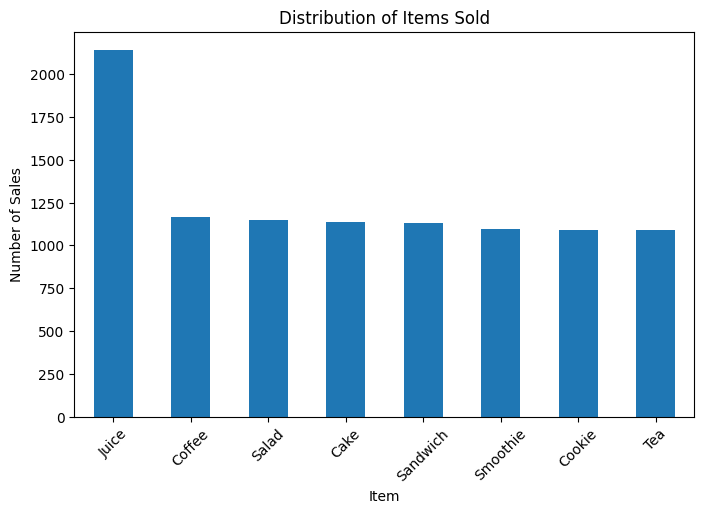

In [4]:
# STEP 4 : DISTRIBUTION OF ITEMS SOLD

# Count how many times each item was sold
item_count = df["Item"].value_counts()

# Display item counts
print(item_count)

# Create a bar chart
plt.figure(figsize=(8,5))

item_count.plot(kind="bar")

# Add chart title
plt.title("Distribution of Items Sold")

# Add x-axis label
plt.xlabel("Item")

# Add y-axis label
plt.ylabel("Number of Sales")

# Rotate x-axis labels
plt.xticks(rotation=45)

# Display graph
plt.show()

Juice is the most frequently sold item, while Tea is among the least sold products.

Payment Method
Digital Wallet    5469
Credit Card       2273
Cash              2258
Name: count, dtype: int64


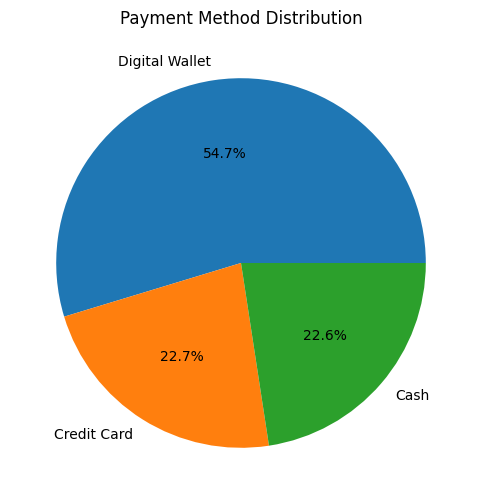

In [5]:
# STEP 5 : PAYMENT METHOD DISTRIBUTION

# Count payment methods
payment_count = df["Payment Method"].value_counts()

# Display payment counts
print(payment_count)

# Create pie chart
plt.figure(figsize=(6,6))

payment_count.plot(
    kind="pie",
    autopct="%1.1f%%"
)

# Remove default y-axis label
plt.ylabel("")

# Add chart title
plt.title("Payment Method Distribution")

# Display graph
plt.show()

Digital Wallet is the most commonly used payment method followed by Cash and Credit Card.

Location
Takeaway    6983
In-store    3017
Name: count, dtype: int64


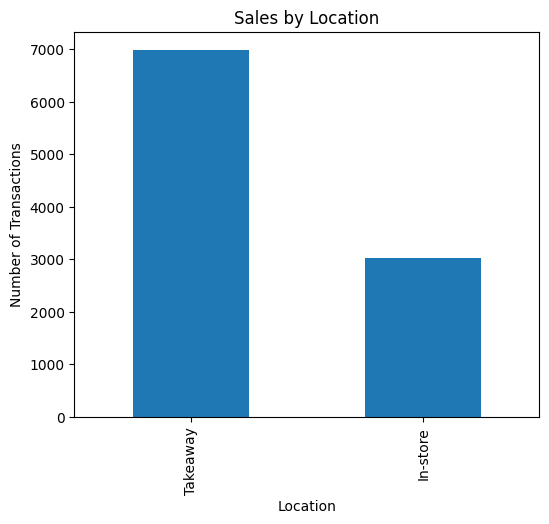

In [6]:
# STEP 6 : SALES BY LOCATION

# Count sales based on location
location_count = df["Location"].value_counts()

# Display counts
print(location_count)

# Create bar chart
plt.figure(figsize=(6,5))

location_count.plot(kind="bar")

# Add chart title
plt.title("Sales by Location")

# Add labels
plt.xlabel("Location")

plt.ylabel("Number of Transactions")

# Display graph
plt.show()

Takeaway orders are higher than In-store purchases.

Item
Cake        10413.0
Coffee       7107.0
Cookie       3256.0
Juice       19079.5
Salad       17365.0
Sandwich    13751.0
Smoothie    13362.0
Tea          4974.0
Name: Total Spent, dtype: float64


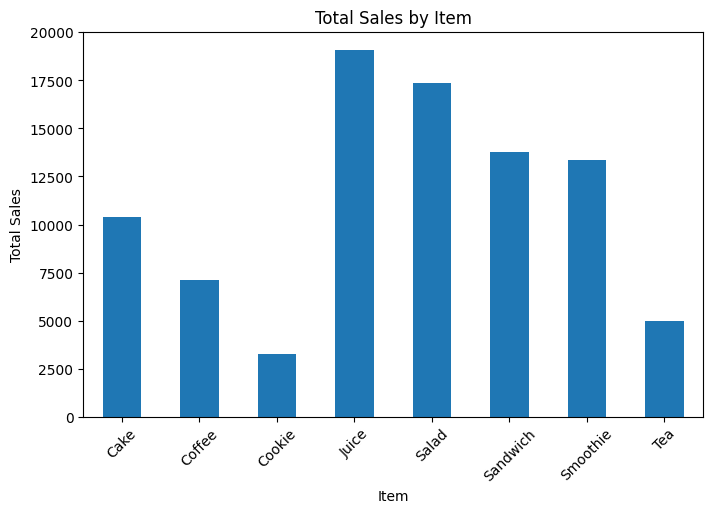

In [7]:
# STEP 7 : TOTAL SALES BY ITEM

# Calculate total sales for each item
sales = df.groupby("Item")["Total Spent"].sum()

# Display total sales
print(sales)

# Create bar chart
plt.figure(figsize=(8,5))

sales.plot(kind="bar")

# Add title
plt.title("Total Sales by Item")

# Add labels
plt.xlabel("Item")

plt.ylabel("Total Sales")

# Rotate labels
plt.xticks(rotation=45)

# Display graph
plt.show()

This graph shows which products generated the highest overall revenue. Juice is the highest followed by Salad

                Quantity  Price Per Unit  Total Spent
Quantity        1.000000        0.005913     0.687133
Price Per Unit  0.005913        1.000000     0.628897
Total Spent     0.687133        0.628897     1.000000


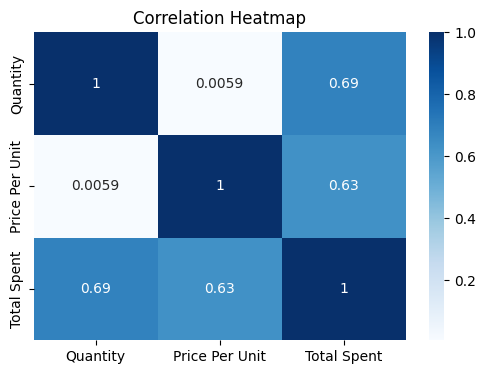

In [8]:
# STEP 8 : CORRELATION SUMMARY

# Select only numerical columns
numeric_columns = df[["Quantity", "Price Per Unit", "Total Spent"]]

# Calculate correlation
correlation = numeric_columns.corr()

# Display correlation values
print(correlation)

# Create heatmap
plt.figure(figsize=(6,4))

sns.heatmap(
    correlation,
    annot=True,
    cmap="Blues"
)

# Add title
plt.title("Correlation Heatmap")

# Display graph
plt.show()

The heatmap shows the relationship between Quantity, Price Per Unit and Total Spent. A stronger positive value indicates a stronger relationship.

Month
April        7574.0
August       7469.5
December     7635.0
February     6950.5
January      7577.5
July         7246.5
June         7697.0
March        7638.0
May          7332.5
November     7290.5
October      7747.5
September    7149.0
Name: Total Spent, dtype: float64


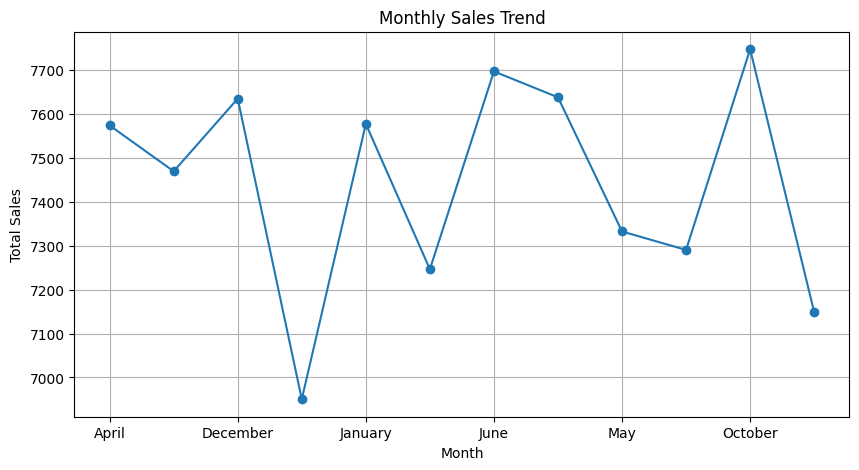

In [9]:
# STEP 9 : MONTHLY SALES TREND

# Convert Transaction Date into datetime format
df["Transaction Date"] = pd.to_datetime(df["Transaction Date"])

# Create a new Month column
df["Month"] = df["Transaction Date"].dt.month_name()

# Calculate monthly sales
monthly_sales = df.groupby("Month")["Total Spent"].sum()

# Display monthly sales
print(monthly_sales)

# Create line chart
plt.figure(figsize=(10,5))

monthly_sales.plot(marker="o")

# Add chart title
plt.title("Monthly Sales Trend")

# Add labels
plt.xlabel("Month")

plt.ylabel("Total Sales")

# Display grid
plt.grid(True)

# Display graph
plt.show()

The line graph shows how total sales changed across different months during the year, October has the highest number of sales.

Item
Juice       2140
Coffee      1165
Salad       1148
Cake        1139
Sandwich    1131
Name: count, dtype: int64


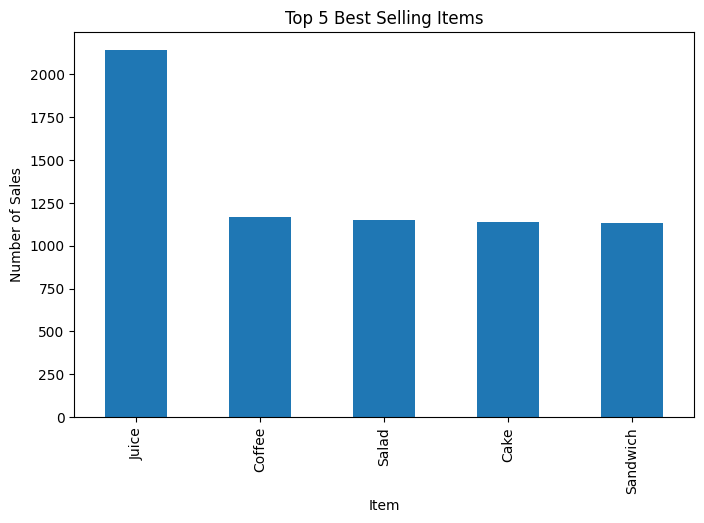

In [10]:
# STEP 10 : TOP 5 BEST SELLING ITEMS

# Display top 5 best selling items
top_items = df["Item"].value_counts().head(5)

# Print top items
print(top_items)

# Create bar chart
plt.figure(figsize=(8,5))

top_items.plot(kind="bar")

# Add title
plt.title("Top 5 Best Selling Items")

# Add labels
plt.xlabel("Item")

plt.ylabel("Number of Sales")

# Display graph
plt.show()

This chart highlights the five most frequently sold products in the cafe.